Question 1

In [4]:
import pandas as pd

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


Question 2

In [6]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5268, Columns: 13


Question 3

In [7]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


Question 4

In [8]:
df.isnull().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

**Time (2219 missing)**
This column has 2219 missing attributes but is still a valuable column especially in crash information so we have decided not to drop it and instead fill it with "Unknown." There is no way to guess a crash time from the other columns anyway.

**Location (20 missing)**
Location has 20 missing attributes and is a critical part of crash info so we are against dropping it as well. For the missing sections we would fill them with "Unknown" as it is not anything we can just replace.

**Operator (18 missing)**
This column only has 18 missing attributes. We cannot guess an airline name from the rest of the row, so we will fill these with "Unknown" instead of dropping them.

**Flight # (4199 missing)**
Flight # has 4199 missing attributes, which is almost 80% of the column. This is too much to fill in without just making up data, and we do not need it for our analysis, so we have decided to drop this column entirely.

**Route (1707 missing)**
Route has 1707 missing attributes, about a third of the column. This is too much to drop, but there is nothing else in the dataset that would help us guess a route. So we will fill these with "Unknown" too.

**Type (27 missing)**
Type only has 27 missing attributes. We cannot infer the aircraft type from other columns, so we will fill these with "Unknown."

**Registration (335 missing)**
Registration has 335 missing attributes. This is basically a unique ID for each plane, so there is no logical way to guess it. We will fill these with "Unknown" as well.

**cn/In (1228 missing)**
cn/In has 1228 missing attributes and is another identifier-type column like Registration. Since it is not needed for our analysis and has a lot missing, we have decided to drop this column.

**Aboard (22 missing)**
Aboard has 22 missing attributes. This column matters for Q7, so instead of dropping rows we will fill it with the median. We chose median over mean because a few crashes involve much bigger planes than usual, which would skew the average.

**Fatalities (12 missing)**
Fatalities has 12 missing attributes. This is the most important column for almost every question after this, so we do not want to guess a number here. We have decided to drop these 12 rows instead, since it is a small enough amount to not affect our results much.

**Ground (22 missing)**
Ground has 22 missing attributes. We believe these are missing because nobody on the ground died in those crashes, not because the data was not recorded. So we will fill these with 0 instead of using the median or mean.

**Question 5**

In [9]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


Question **6**

In [10]:
fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object

**Question 7**

In [11]:
no_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print(f"Number of crashes with zero fatalities: {no_fatalities.shape[0]}")
no_fatalities.head()

Number of crashes with zero fatalities: 58


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0


In [12]:
fatality_locations[['Aboard', 'Fatalities']].describe()

,Aboard,Fatalities
count,5246.000000,5256.000000
mean,27.554518,20.068303
std,43.076711,33.199952
min,0.000000,0.000000
25%,5.000000,3.000000
50%,13.000000,9.000000
75%,30.000000,23.000000
max,644.000000,583.000000


Comparing Aboard and Fatalities, on average about 20 out of 27 people aboard died in a crash, so most crashes have a pretty high fatality rate. The worst case was the Tenerife crash on 03/27/1977 with 644 aboard and 583 fatalities.

There are 58 recorded crashes with zero fatalities, meaning everyone aboard survived. A few examples are the English Channel crash in 1926 (12 aboard, 0 fatalities) and the Amsterdam crash in 1953 (34 aboard, 0 fatalities). So even though most crashes are fatal, there's a decent number where nobody died.

**Question 8**

In [13]:
fatality_locations[['Region', 'State_Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)

fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State_Country'] = fatality_locations['State_Country'].str.strip()

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,NaN
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


**Question 9**

In [14]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


**Question 10**

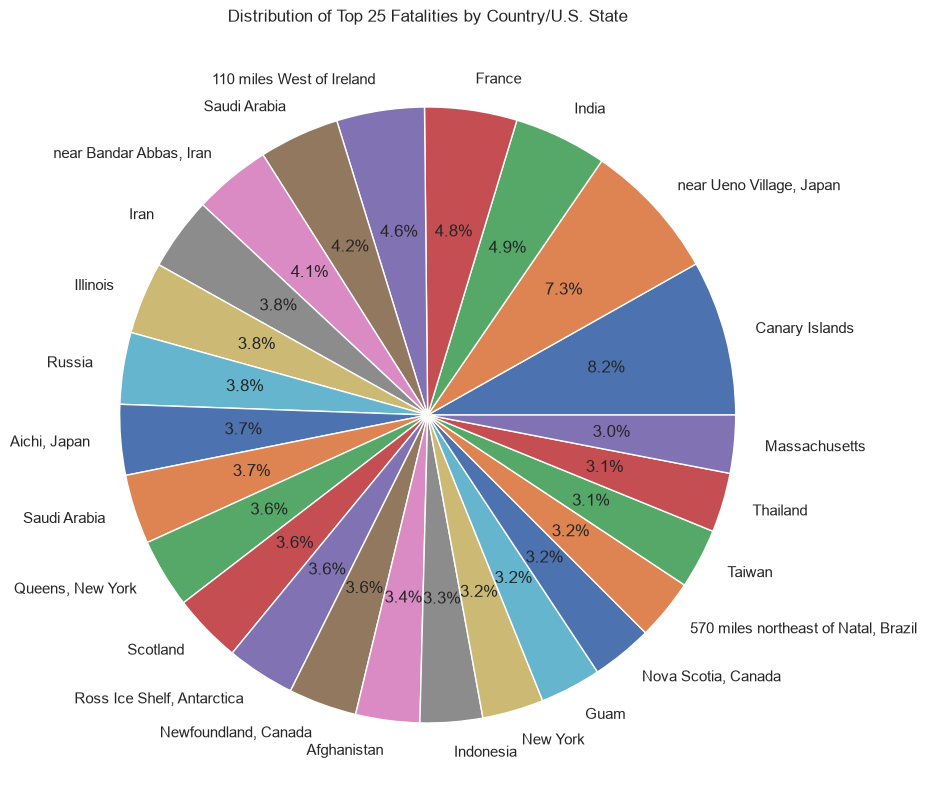

In [18]:

import seaborn as sns
import matplotlib.pyplot as plt

top_25 = fatality_locations.sort_values(by='Fatalities', ascending=False).head(25)

plt.figure(figsize=(10, 10))
plt.pie(top_25['Fatalities'], labels=top_25['State_Country'], autopct='%1.1f%%')
plt.title('Distribution of Top 25 Fatalities by Country/U.S. State')
plt.show()

sns.set_theme(style="whitegrid")